# Advection Equation

Here we solve the advection equation $u_t + a u_x=0$ using a step function $u(x, t = 0) = 1$ for x ∈ [4, 6] and $u(x, t = 0) = 0$ in the rest of the domain.

We use a domain $x\in [0,10]$ with periodic boundary conditions and use the Lax - Friedrichs scheme.

nx= 101
dx= 0.1
dt= 0.09000000000000001
Number of iterations= 222.2222222222222


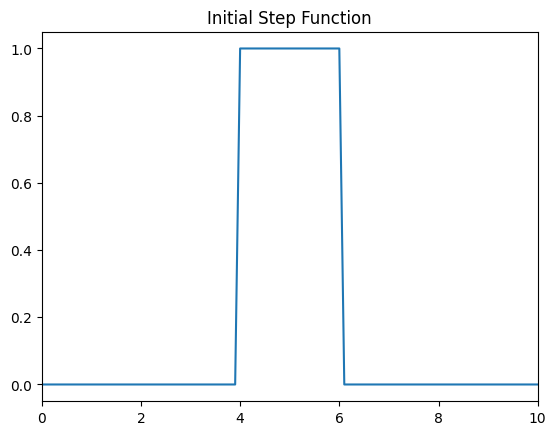

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#define the speed a
a=1.0

# Define the domain
L = 10.0     # Domain length
nx = 101    # Number of grid points
dx = L/(nx-1)   # Grid spacing
x = np.linspace(0, L, nx)
##print(x,'\n',dx) #just a check

# Define the time step and the final time
cf = 0.9
dt = cf*dx/a   # Time step
t_final = 20.0

print('nx=',nx)
print('dx=',dx)
print('dt=',dt)
print('Number of iterations=',t_final/dt)


# Define the initial condition
x1, x2 = 4.0, 6.0
u_initial = np.zeros(nx)
i = 0
for xi in x:
    if (xi>= x1) and (xi <= x2): u_initial[i] = 1
    i+= 1

plt.plot(x, u_initial)
plt.title('Initial Step Function')
plt.xlim(0, 10)
plt.show()

# Initialize the solution array
u_current = u_initial.copy()

#we create arrays where we will store the time and the l2norm
l2norm=[]
l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))

time=[]
time.append(0.0)

Decreasing the Courant Factor dampens out the stap function, i.e using cf = 0.2 reduces the peak down to around 0.2 at t = 20. As expected, increasing cf (i did 0.7) reduces the dampening: the peak is now around 0.6. 

In [2]:
import os
##create directory where to save images
print(os.getcwd())

#os.makedirs('./img_SF_LF')

os.listdir('./')

C:\Users\lm101\Desktop\Uni\numerical_relativity_2025\Advection


['.ipynb_checkpoints',
 'Advection_Equation.ipynb',
 'Advection_Equation_Leapfrog.ipynb',
 'Advection_Equation_LF.ipynb',
 'Advection_Equation_LW.ipynb',
 'AE_Step_LF.ipynb',
 'AE_Step_LW.ipynb',
 'images',
 'images_Leapfrog',
 'images_LF',
 'images_LW',
 'img_SF_LF',
 'img_SF_LW',
 'l2norm_FTCS.dat',
 'l2norm_LAX.dat',
 'l2norm_LAXWENDROFF.dat',
 'l2norm_LEAPFROG.dat',
 'movie.mp4',
 'movie_Leapfrog.mp4',
 'movie_LF.mp4',
 'movie_LW.mp4',
 'movie_SF_LF.mp4',
 'movie_SF_LW.mp4',
 'README.md']

In [3]:
# Initilize time and iteration counter
t = 0.0
i = 0

#save the initial conditions
plt.plot(x, u_current)
plt.title('Time='+str(round(t,2)))
plt.ylim(-0.2,1.1)
plt.savefig('./img_SF_LF/fig_'+str(i).zfill(5)+'.png', dpi=200)
plt.close()

#solve the advection equation
while t < t_final:
    # Compute the new solution using the L-F method
    # Note: np.roll(u_current, -1) is equivalent to u(j+1) and
    #       np.roll(u_current,  1) is equivalent to u(j-1)
    # using np.roll is equivalent to use periodic boundary conditions
    u_next = 0.5 * (np.roll(u_current, -1) + np.roll(u_current, 1)) - a*dt/(2*dx)*(np.roll(u_current, -1) - np.roll(u_current, 1))    
    
    u_1 =  0.5 * (np.roll(u_current, -1) + np.roll(u_current, 1))
    u_2 = - a*dt/(2*dx)*(np.roll(u_current, -1) - np.roll(u_current, 1))    
    # Update the solution
    u_current = u_next.copy()
    
    
    #advance the time 
    t += dt
    i += 1
    
    #compute the l2 norm and add the time to the time vector
    l2norm.append(np.sqrt(np.sum(u_current**2)/len(u_current)))
    time.append(t)
    
    #plot the current result and save in an image every 10 iterations
    if (i%10==0):
        plt.plot(x, u_current, color = 'black', label = 'sum')
        plt.plot(x, u_1, color = 'blue', label = 'term1')
        plt.plot(x, u_2, color = 'red', label = 'term2')
        plt.title('Time='+str(round(t,2)))
        plt.legend()
        plt.ylim(-0.2,1.1)
        plt.savefig('./img_SF_LF/fig_'+str(i).zfill(5)+'.png', dpi=200)
        plt.close()


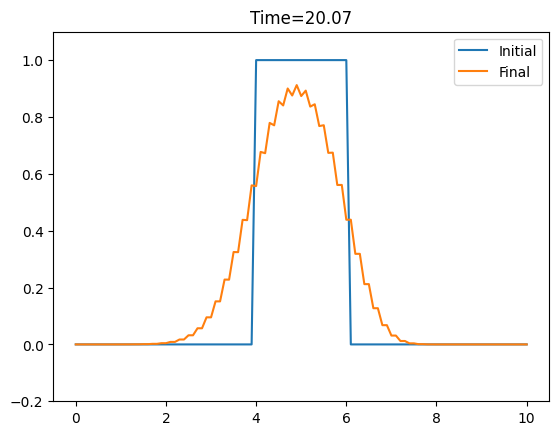

In [4]:
# Plot the final solution
plt.plot(x, u_initial, label='Initial')
plt.plot(x, u_current, label='Final')
plt.title('Time='+str(round(t,2)))
plt.ylim(-0.2,1.1)
plt.legend()
plt.show()

In [5]:
# set the directory where your images are stored
directory = "./img_SF_LF/"

# get the list of image files in the directory
files = os.listdir(directory)

print(files, '\n')

# sort the files in alphanumeric order
files=sorted(files)

print(files)




['fig_00000.png', 'fig_00010.png', 'fig_00020.png', 'fig_00030.png', 'fig_00040.png', 'fig_00050.png', 'fig_00060.png', 'fig_00070.png', 'fig_00080.png', 'fig_00090.png', 'fig_00100.png', 'fig_00110.png', 'fig_00120.png', 'fig_00130.png', 'fig_00140.png', 'fig_00150.png', 'fig_00160.png', 'fig_00170.png', 'fig_00180.png', 'fig_00190.png', 'fig_00200.png', 'fig_00210.png', 'fig_00220.png'] 

['fig_00000.png', 'fig_00010.png', 'fig_00020.png', 'fig_00030.png', 'fig_00040.png', 'fig_00050.png', 'fig_00060.png', 'fig_00070.png', 'fig_00080.png', 'fig_00090.png', 'fig_00100.png', 'fig_00110.png', 'fig_00120.png', 'fig_00130.png', 'fig_00140.png', 'fig_00150.png', 'fig_00160.png', 'fig_00170.png', 'fig_00180.png', 'fig_00190.png', 'fig_00200.png', 'fig_00210.png', 'fig_00220.png']


In [6]:
from moviepy import ImageSequenceClip

clip = ImageSequenceClip('./img_SF_LF/', fps = 7)
clip.write_videofile('movie_SF_LF.mp4')
clip.close()

MoviePy - Building video movie_SF_LF.mp4.
MoviePy - Writing video movie_SF_LF.mp4



MoviePy - Done !
MoviePy - video ready movie_SF_LF.mp4


In [7]:
# don't worry about the code in this cell, it is just to let you 
# display the movies you generated above in Jupyter notebook
from IPython.display import HTML

HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="./movie_SF_LF.mp4" type="video/mp4">
</video></div>""")

it's nice (?) to see the terms separately: it seems like the second term doesn't really affect the oscillations as much as the first one does, it instead only acts to heigthen or shorten the curve. Meaning that the oscillations are only due to the average of the two points from the previous step? could be: it accumulates the error of the averages over time until it's really far away from the initial curve. This makes sense, if we now raise the number of points by a lot (i.e. 801), it resembles the initial shape much more. This is also consistent with the fact that this is a first order method: the error goes as dx and increasing the number of point reduces it.

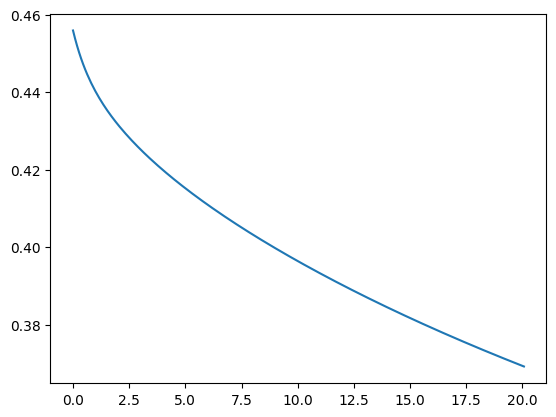

In [8]:
plt.plot(time,l2norm)
plt.show()